# Data Downloads, Import
- 교재와 동일한 결과를 얻기 위해 랜덤 시드를 지정

In [ ]:
import torch

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True


In [2]:
from torchvision.datasets import FashionMNIST

fm_train = FashionMNIST(root='./data/', train=True, download=False)
fm_test = FashionMNIST(root='./data/', train=False, download=False)

In [4]:
type(fm_train.data)

torch.Tensor

In [3]:
print(fm_train.data.shape, fm_test.data.shape)
print(fm_train.targets.shape, fm_test.targets.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])
torch.Size([60000]) torch.Size([10000])


- 교재에서 사용된 28 $\times$ 28 짜리 이미지 인것을 확인할 수 있고, Train 데이터는 60000장, Test 데이터는 10000장으로 확인

In [10]:
train_input = fm_train.data
train_target = fm_train.targets

In [11]:
train_scaled = train_input / 255.0

In [12]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [14]:
print(train_scaled.shape, val_scaled.shape)

torch.Size([48000, 28, 28]) torch.Size([12000, 28, 28])


# 기본 신경망 모델
## 모델 구축
- Keras와 동일하게 모델을 구축하는 과정이 있음
- 은닉층, 활성화 함수 들을 지정

In [15]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 100),
    nn.ReLU(),
    nn.Linear(100,10)
)

- Keras 처럼 summary 기능을 하는 `torchinfo` 라이브러리가 존재

In [16]:
from torchinfo import summary
summary(model, input_size = (32, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─Flatten: 1-1                           [32, 784]                 --
├─Linear: 1-2                            [32, 100]                 78,500
├─ReLU: 1-3                              [32, 100]                 --
├─Linear: 1-4                            [32, 10]                  1,010
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.54
Input size (MB): 0.10
Forward/backward pass size (MB): 0.03
Params size (MB): 0.32
Estimated Total Size (MB): 0.45

- Keras의 summary 정보 처럼 현재 구축한 모델이 어떤 층으로 구성되었는지, 뉴런이 있는 층의 경우 파라미터 수가 어떻게 되는지 파악이 가능

In [17]:
# GPU 모델이 있는 경우 쿠다 언어 사용을 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=10, bias=True)
)

## 옵티마이저 적용
- `torch` 라이브러리 내에 `optim` 불러와서 진행
- 7장에서 배운 SGD를 비롯한 알고리즘을 해당 단계에서 적용

In [18]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [19]:
for params in model.parameters():
    print(params.shape)

torch.Size([100, 784])
torch.Size([100])
torch.Size([10, 100])
torch.Size([10])


## Epochs 설정 및 모델 학습 진행

In [20]:
epochs = 5
batches = int(len(train_scaled)/32)
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for i in range(batches):
        inputs = train_scaled[i*32:(i+1)*32].to(device)
        targets = train_target[i*32:(i+1)*32].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"에포크:{epoch + 1}, 손실:{train_loss/batches:.4f}")

에포크:1, 손실:0.5428
에포크:2, 손실:0.4004
에포크:3, 손실:0.3593
에포크:4, 손실:0.3318
에포크:5, 손실:0.3121


## 모델 평가
- `eval()` 사용

In [21]:
model.eval()
with torch.no_grad():
    val_scaled = val_scaled.to(device)
    val_target = val_target.to(device)
    outputs = model(val_scaled)
    predicts = torch.argmax(outputs, 1)
    corrects = (predicts == val_target).sum().item()

accuracy = corrects / len(val_target)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.8738


# 심층 신경망 모델
## Droput 적용 방법

In [23]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 100),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(100, 10)
)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=100, out_features=10, bias=True)
)

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## 조기 종료 진행 방법

In [31]:
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 20
batches = int(len(train_scaled)/32)
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for i in range(batches):
        inputs = train_scaled[i*32:(i+1)*32].to(device)
        targets = train_target[i*32:(i+1)*32].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        val_scaled = val_scaled.to(device)
        val_target = val_target.to(device)
        outputs = model(val_scaled)
        loss = criterion(outputs, val_target)
        val_loss = loss.item()

    train_hist.append(train_loss/batches)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},",
          f"훈련 손실:{train_loss/batches:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), './model/best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.3099, 검증 손실:0.3324
에포크:2, 훈련 손실:0.3032, 검증 손실:0.3249
에포크:3, 훈련 손실:0.2996, 검증 손실:0.3239
에포크:4, 훈련 손실:0.2983, 검증 손실:0.3328
에포크:5, 훈련 손실:0.2937, 검증 손실:0.3273
5번째 에포크에서 조기 종료되었습니다.


# 그래프로 결과 확인
- matplot으로 진행

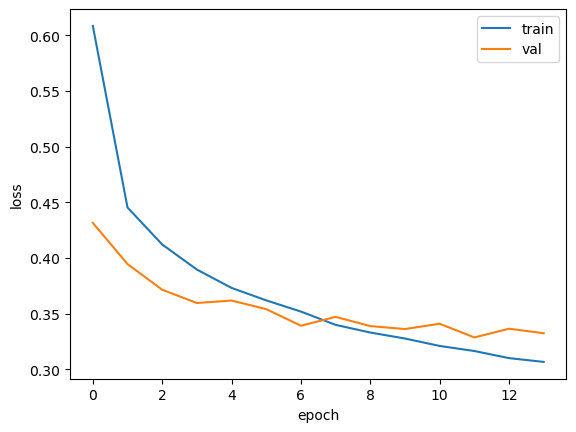

In [27]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [28]:
model.load_state_dict(torch.load('best_model.pt', weights_only=True))

<All keys matched successfully>

In [30]:
model.eval()
with torch.no_grad():
    val_scaled = val_scaled.to(device)
    val_target = val_target.to(device)
    outputs = model(val_scaled)
    predicts = torch.argmax(outputs, 1)
    corrects = (predicts == val_target).sum().item()

accuracy = corrects / len(val_target)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.882
